Long-term impact results of PAH toxicity from MPRI2 spill scenarios at Turn Point/Haro Strait

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
import ssam_plot as splot
from mpl_toolkits.axes_grid1 import make_axes_locatable

### Define scenario and control files

| Scenarios	|	Description |
|-----------|---------------|
| 1	|	30-day fisheries closures |
| 2	|	90-day fisheries closures |
| 3	|	spill containment within 48hrs + 30-day fisheries closures |
| 4	|	spill containment within 48hrs + 90-day fisheries closures |

8 simulations for each scenario
| Fraser flow	|	Season |
|-----------|---------------|
| low Fraser	|	winter |
| high Fraser	|	spring |
| 	|	summer |
| 	|	fall |

In [2]:
hex_colour = '#6DB48E'
hatches = ['oo', '///', 'xx', '++']
alphas = [0.5, 0.75, 0.3, 1]
#colors = plt.cm.tab10.colors

In [3]:
# Read in salish sea atlantis output files.
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/control-2039-2042/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])


In [4]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
scenario_paths = sorted([p for p in scenario_root.glob('highres-2039-2042_5b*/outputSalishSea.nc')])
for path in scenario_paths:
    print(path.parent.stem, groups.conditions[str(path.parent.stem).split(sep = '_')[3]])

highres-2039-2042_5b_1_2019-01-20 low Fraser winter
highres-2039-2042_5b_1_2020-01-24 high Fraser winter
highres-2039-2042_5b_2_2019-01-20 low Fraser winter
highres-2039-2042_5b_2_2020-01-24 high Fraser winter


In [5]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [ ]:
# time after burn-in
start = 0
end = time.size-1

#### Concentration of PAH in seawater

PAH Half lives

| 	|	Naphthalene |	Phenanthrene | Pyrene |	Benzo(a)pyrene |
|-------------------|---------------|-----------------|--------|----------|
| Half life (secs)	|	259200 |	3628800	| 20476800	| 19353600 |
| Half life (days)	|	3	| 42 |	237 |	224 |

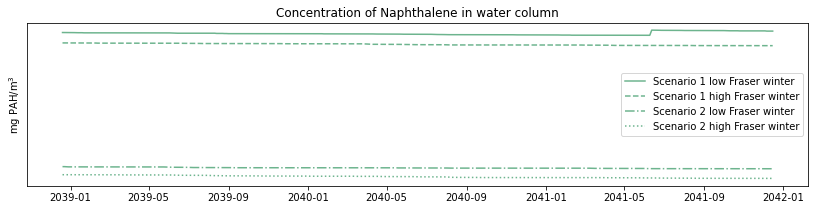

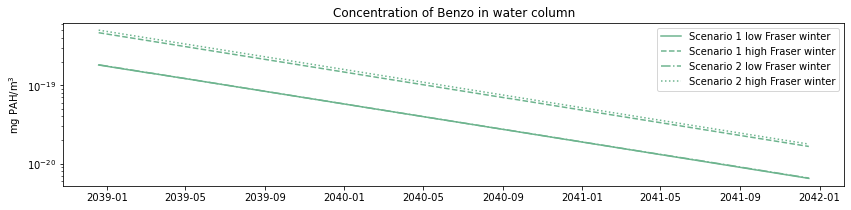

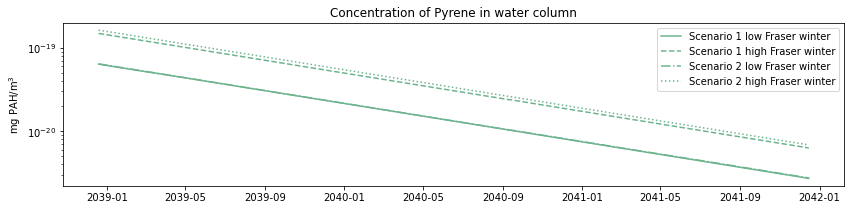

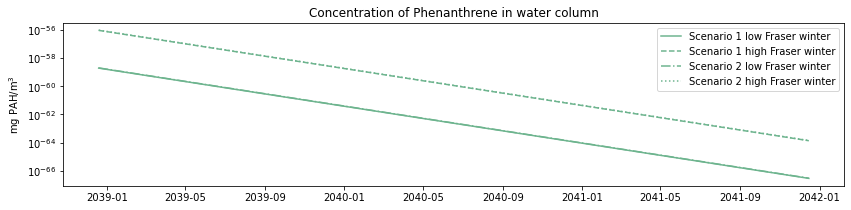

In [10]:
#Contaminants remaining at the end of the simulation
for pah in groups.pahs:
  fig, ax = plt.subplots(figsize = (14,3))
  names = []
  line_styles = itertools.cycle(('-', '--', '-.', ':',(5, (10, 3)),
    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))
  for scenario, path, i in zip(scenario_datasets,scenario_paths,range(0,len(scenario_datasets))):
      nm = 'Scenario '+str(path.parent.stem).split(sep = '_')[2]+' '+groups.conditions[str(path.parent.stem).split(sep = '_')[3]]
      names.append(nm)
      contam_tbl = scenario.variables[str(pah)][start:end,:,0:6]
      contam_t = contam_tbl.sum(axis=(1,2))
      ax.semilogy(scenario.t[start:end], contam_t, color=hex_colour, linestyle=next(line_styles))
  ax.set_title('Concentration of '+ pah +' in water column', fontsize = 12)
  ax.set_ylabel('mg PAH/m$^3$')
  ax.legend(names, loc='best')

### Calculate Mean of Final 3 years (2039-2042)

In [7]:
def mean_data_pelagic(bio_group, location=groups.salish_sea):
    results = []
    for scenario, path in zip(scenario_datasets,scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][start:end, location, 0:6], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][start:end, location, 0:6], np.nan)
            p_oiled = p_oiled.sum(axis=(1,2)).mean()
            p_control = p_control.sum(axis=(1,2)).mean()
            p_ratio = (p_oiled / p_control - 1) * 100
            
            results.append({
            'bio_group': species,
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen"+scenario_name+"_"+bio_group[species]+".csv")
    
    bio_groups = df['bio_group'].unique()
    scenarios = df['scenario'].unique()

    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
        n_rows = n_rows

    fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharey=True)

    bar_width = 0.9 / len(scenarios)  
    y_pos = np.arange(len(bio_groups))

    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
    ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=16) 
    #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(scenarios, bbox_to_anchor=(1.5, 0.9),  fontsize=14) #bbox_to_anchor=(0.8, 1.2) ncol=len(scenarios),
    plt.show()

In [8]:
def mean_data_benthic(bio_group, location=groups.salish_sea):
    results = []
    for scenario, path in zip(scenario_datasets,scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]

        for species in bio_group: 
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][start:end, location], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][start:end, location], np.nan)
            p_oiled = p_oiled.sum(axis=1).mean()
            p_control = p_control.sum(axis=1).mean()
            p_ratio = (p_oiled / p_control - 1) * 100
            
            results.append({
            'bio_group': species,
            'scenario': scenario_name,
            'percent_change': p_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen"+scenario_name+"_"+bio_group[species]+".csv")

    bio_groups = df['bio_group'].unique()
    scenarios = df['scenario'].unique()
    
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
        n_rows = n_rows

    fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharey=True)

    bar_width = 0.9 / len(scenarios)  
    y_pos = np.arange(len(bio_groups))

    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
    ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=16) 
    #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(scenarios, bbox_to_anchor=(1.5, 0.9),  fontsize=14) #bbox_to_anchor=(0.8, 1.2) ncol=len(scenarios),
    plt.show()

In [9]:
def mean_data_vertebrates_all_cohorts(bio_group, location=groups.salish_sea):
    results = []

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]

        for species in bio_group:
            numCohorts = groups.cohorts[bio_group[species]]
            sum_ratio = 0

            for cohort in range (1, numCohorts+1):

                new_species = bio_group[species] + str(cohort)
            
                o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:end, location, 0:6], np.nan)
                o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:end, location, 0:6], np.nan)
                o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:end, location, 0:6], np.nan)

                c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:end, location, 0:6], np.nan)
                c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:end, location, 0:6], np.nan)
                c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:end, location, 0:6], np.nan)

                o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
                o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

                c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
                c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

                ratio = (o_weightatage / c_weightatage - 1) * 100
                #print(ratio)
                sum_ratio = sum_ratio + ratio

            results.append({
            'bio_group': species,
            'scenario': scenario_name,
            'percent_change': sum_ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen"+scenario_name+"_"+bio_group[species]+"_ALLcohorts.csv")

In [10]:
def mean_data_vertebrate_juveniles(bio_group, location=groups.salish_sea):
    results = []

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]

        for species in bio_group:
            numCohorts = groups.cohorts[bio_group[species]]
            sum_ratio = 0

            new_species = bio_group[species] + '2'
        
            o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:end, location, 0:6], np.nan)
            o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:end, location, 0:6], np.nan)
            o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:end, location, 0:6], np.nan)

            c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:end, location, 0:6], np.nan)
            c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:end, location, 0:6], np.nan)
            c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:end, location, 0:6], np.nan)

            o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
            o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

            c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
            c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

            ratio = (o_weightatage / c_weightatage - 1) * 100

            results.append({
            'bio_group': species,
            'scenario': scenario_name,
            'percent_change': ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen"+scenario_name+"_"+bio_group[species]+"_juveniles.csv")

    bio_groups = df['bio_group'].unique()
    scenarios = df['scenario'].unique()
    
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
        n_rows = n_rows

    fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharey=True)

    bar_width = 0.9 / len(scenarios)  
    y_pos = np.arange(len(bio_groups))

    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
    ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=16) 
    #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(scenarios, bbox_to_anchor=(1.5, 0.9),  fontsize=14) #bbox_to_anchor=(0.8, 1.2) ncol=len(scenarios),
    plt.show()

In [11]:
def mean_data_vertebrate_adults(bio_group, location=groups.salish_sea):
    results = []

    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]

        for species in bio_group:
            numCohorts = groups.cohorts[bio_group[species]]
            sum_ratio = 0

            new_species = bio_group[species] + '5'
        
            o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:end, location, 0:6], np.nan)
            o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:end, location, 0:6], np.nan)
            o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:end, location, 0:6], np.nan)

            c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:end, location, 0:6], np.nan)
            c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:end, location, 0:6], np.nan)
            c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:end, location, 0:6], np.nan)

            o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
            o_weightatage = o_weightatage_tbl.sum(axis=(1,2)).mean()

            c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
            c_weightatage = c_weightatage_tbl.sum(axis=(1,2)).mean()

            ratio = (o_weightatage / c_weightatage - 1) * 100

            results.append({
            'bio_group': species,
            'scenario': scenario_name,
            'percent_change': ratio,
            'sensitivity': groups.sensitivity[bio_group[species]],
            'sensitivity_negative': -groups.sensitivity[bio_group[species]],
            })

    df = pd.DataFrame(results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen"+scenario_name+"_"+bio_group[species]+"_adults.csv")

    bio_groups = df['bio_group'].unique()
    scenarios = df['scenario'].unique()
    
    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
        n_rows = n_rows

    fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharey=True)

    bar_width = 0.9 / len(scenarios)  
    y_pos = np.arange(len(bio_groups))

    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, facecolor=hex_colour, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
    ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=16) 
    #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(scenarios, bbox_to_anchor=(1.5, 0.9),  fontsize=14) #bbox_to_anchor=(0.8, 1.2) ncol=len(scenarios),
    plt.show()

In [12]:
def box_plot(df, x_lim=None):
    scenarios = df['scenario'].unique()
    bio_groups = df['bio_group'].unique()

    hatches = ['oo', '///', 'xx', '++']
    alphas = [0.5, 0.75, 0.3, 1]

    n_rows = len(bio_groups)
    if n_rows < 7:
        n_rows = 7
    elif n_rows >10:
        n_rows = 15
    else:
        n_rows = n_rows

    fig, ax = plt.subplots(1, 1, figsize=(4, 6), sharey=True)

    bar_width = 0.9 / len(scenarios)  
    y_pos = np.arange(len(bio_groups))

    for j, scenario in enumerate(scenarios):
        df_plot = df[(df['scenario'] == scenario)]
        df_plot = df_plot.set_index('bio_group').reindex(bio_groups)  
        offset = (j - len(scenarios)/2) * bar_width + bar_width/2

        ax.barh(y_pos + offset, df_plot['percent_change'], height=bar_width, label=scenario, alpha=alphas[j], edgecolor='black', hatch=hatches[j])
    ax.barh(bio_groups, df_plot['sensitivity'], color='grey', alpha=0.3)
    ax.barh(bio_groups, df_plot['sensitivity_negative'], color='grey', alpha=0.3)
    ax.xaxis.grid(True)
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(bio_groups, fontsize=16) 
    ax.set_xlim(x_lim)
    #ax.set_xlabel("Percent Change", fontsize=16)

    fig.legend(scenarios, bbox_to_anchor=(1.5, 0.9),  fontsize=14) #bbox_to_anchor=(0.8, 1.2) ncol=len(scenarios),
    plt.show()

In [ ]:
mean_data_benthic(groups.benthos)

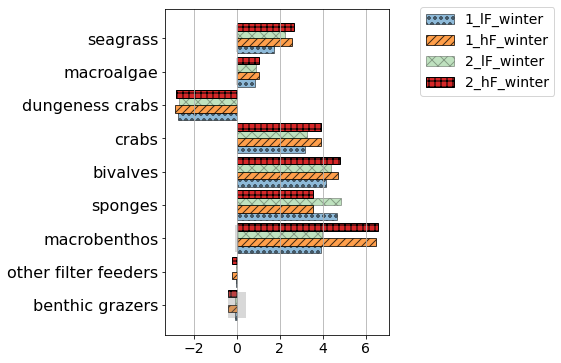

In [13]:
box_plot(pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen2_hF_winter_Seagrass.csv"))

In [ ]:
mean_data_pelagic(groups.planktonic)

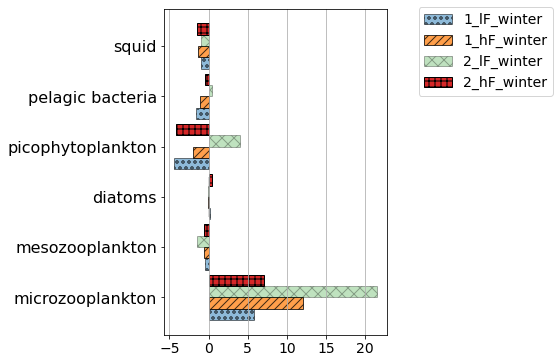

In [14]:
box_plot(pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen2_hF_winter_Squid.csv"))

In [ ]:
mean_data_vertebrate_adults(groups.wild_salmon)

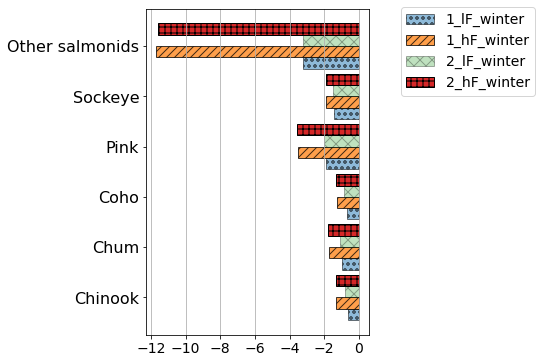

In [15]:
box_plot(pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen2_hF_winter_Other_salmonids_adults.csv"))

In [ ]:
mean_data_vertebrate_adults(groups.named_fish)

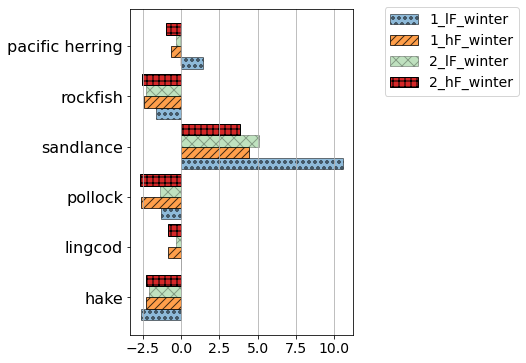

In [16]:
box_plot(pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen2_hF_winter_Pacific_herring_adults.csv"))

In [ ]:
mean_data_vertebrate_adults(groups.mammals)

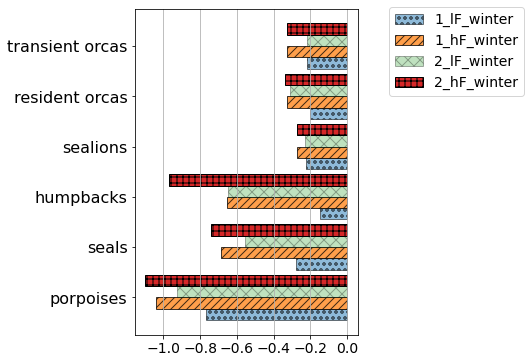

In [17]:
box_plot(pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/Scen2_hF_winter_Orcas_transient_adults.csv"))

In [24]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
results_paths = sorted([p for p in results_root.glob('Scen*.csv')])
mean_data = []
for file in results_paths:
    df1 = pd.read_csv(file)
    mean_data.append(df1[['bio_group', 'scenario', 'percent_change','sensitivity','sensitivity_negative']])

mean_data_df = pd.concat(mean_data, ignore_index=True)
mean_data_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/mean_data.csv")

## Start here if mean data already calculated

In [18]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/mean_data.csv")

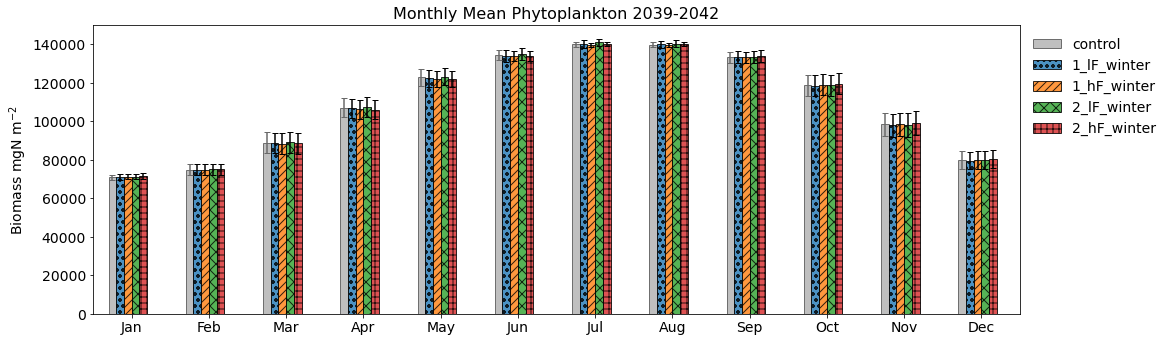

In [20]:
location = groups.salish_sea
fig, ax = plt.subplots(figsize=(14, 5))

fig.tight_layout(pad=2.5)

bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 1}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
these_hatches = itertools.cycle(hatches)

width=0.1

control_tbl = control.Diatom_N[start:end,location,0:6] + control.PicoPhytopl_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 

ax.bar(xticks-0.25, control_monthly_mean,width,yerr=control_std,color='grey',ecolor='dimgrey',edgecolor='k',label='control',alpha=0.5,capsize=3) #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.Diatom_N[start:end,location,0:6] + scenario.PicoPhytopl_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]
    offset = ((list(scenario_paths).index(path))- len(scenario_paths)/2) * width + width/2
    ax.bar(xticks + offset, scenario_monthly_mean,width,yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,label=name) #lightgreen
    #ax.fill_between(xticks,NPGO_C_D_mean,color='black',hatch='//',alpha=.3,label='Diatoms') #lightgreen
    #offset = offset + 0.1
    
ax.set_title('Monthly Mean Phytoplankton 2039-2042',fontsize=16)
ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14) #fontsize=14, loc="upper center", ncol=len(scenario_paths)+1) #upper left
#ax.set_ylim(0,100000)
ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

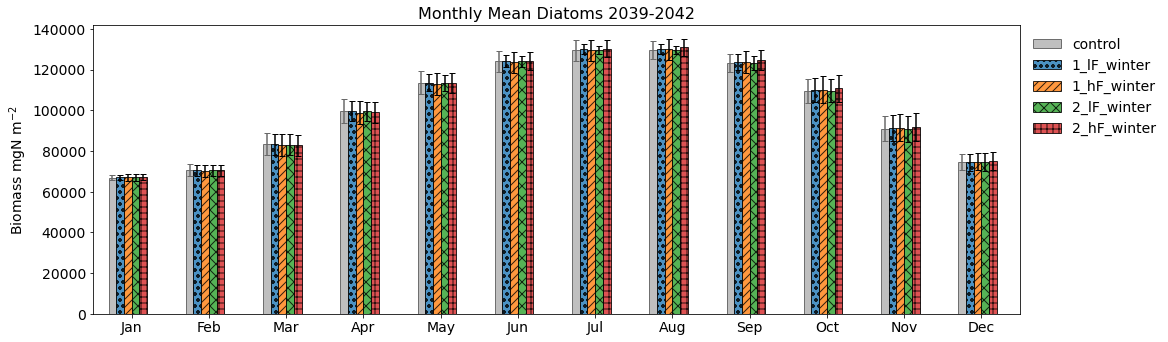

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.tight_layout(pad=2.5)

bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 1}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
these_hatches = itertools.cycle(hatches)

width=0.1

control_tbl = control.Diatom_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 

ax.bar(xticks-0.25, control_monthly_mean,width,yerr=control_std,color='grey',ecolor='dimgrey',edgecolor='k',label='control',alpha=0.5,capsize=3) #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.Diatom_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]
    offset = ((list(scenario_paths).index(path))- len(scenario_paths)/2) * width + width/2
    ax.bar(xticks + offset, scenario_monthly_mean,width,yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,label=name) #lightgreen
    #ax.fill_between(xticks,NPGO_C_D_mean,color='black',hatch='//',alpha=.3,label='Diatoms') #lightgreen
    #offset = offset + 0.1
    
ax.set_title('Monthly Mean Diatoms 2039-2042',fontsize=16)
ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14) #fontsize=14, loc="upper center", ncol=len(scenario_paths)+1) #upper left
#ax.set_ylim(0,100000)
ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

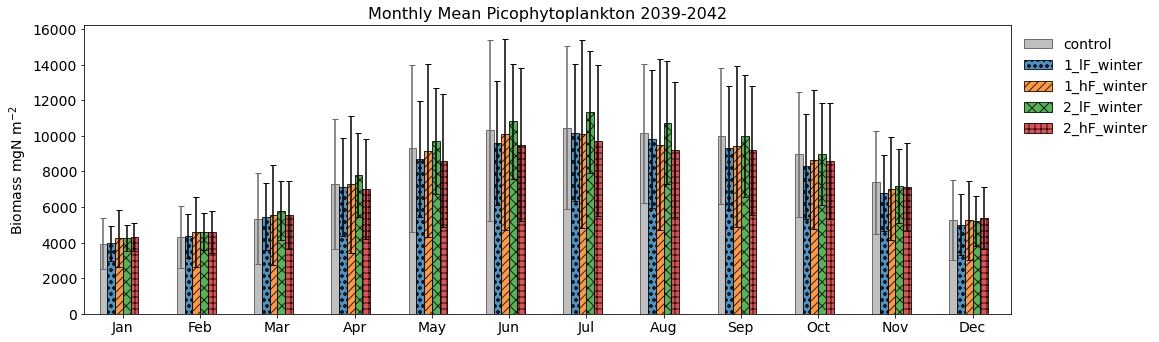

In [22]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.tight_layout(pad=2.5)

bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 1}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
these_hatches = itertools.cycle(hatches)

width=0.1

control_tbl = control.PicoPhytopl_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 

ax.bar(xticks-0.25, control_monthly_mean,width,yerr=control_std,color='grey',ecolor='dimgrey',edgecolor='k',label='control',alpha=0.5,capsize=3) #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.PicoPhytopl_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]
    offset = ((list(scenario_paths).index(path))- len(scenario_paths)/2) * width + width/2
    ax.bar(xticks + offset, scenario_monthly_mean,width,yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,label=name) #lightgreen
    #ax.fill_between(xticks,NPGO_C_D_mean,color='black',hatch='//',alpha=.3,label='Diatoms') #lightgreen
    #offset = offset + 0.1
    
ax.set_title('Monthly Mean Picophytoplankton 2039-2042',fontsize=16)
ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14) #fontsize=14, loc="upper center", ncol=len(scenario_paths)+1) #upper left
#ax.set_ylim(0,100000)
ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

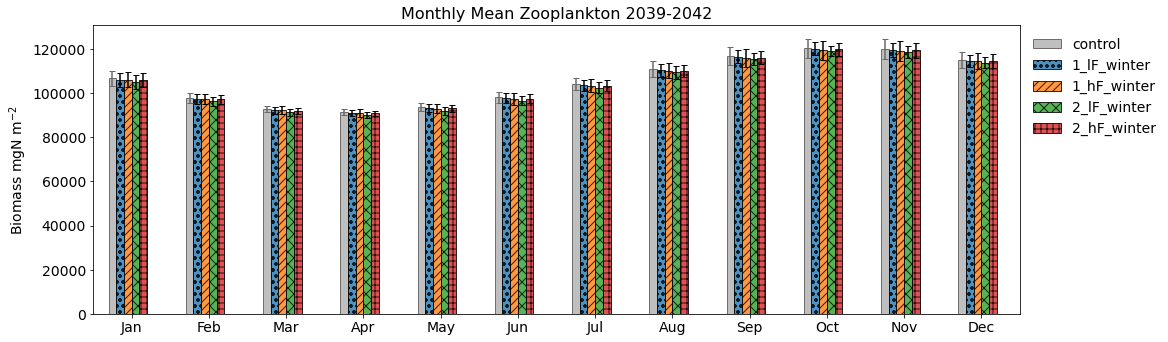

In [23]:
fig, ax = plt.subplots(figsize=(14, 5))

fig.tight_layout(pad=2.5)

bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 1}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
these_hatches = itertools.cycle(hatches)

width=0.1

control_tbl = control.MicroZoo_N[start:end,location,0:6] + control.Zoo_N[start:end,location,0:6] + control.Gelat_Zoo_N[start:end,location,0:6] + control.Carniv_Zoo_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 

ax.bar(xticks-0.25, control_monthly_mean,width,yerr=control_std,color='grey',ecolor='dimgrey',edgecolor='k',label='control',alpha=0.5,capsize=3) #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.MicroZoo_N[start:end,location,0:6] + scenario.Zoo_N[start:end,location,0:6] + scenario.Gelat_Zoo_N[start:end,location,0:6] + scenario.Carniv_Zoo_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]
    offset = ((list(scenario_paths).index(path))- len(scenario_paths)/2) * width + width/2
    ax.bar(xticks + offset, scenario_monthly_mean,width,yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,label=name) #lightgreen
    #ax.fill_between(xticks,NPGO_C_D_mean,color='black',hatch='//',alpha=.3,label='Diatoms') #lightgreen
    #offset = offset + 0.1
    
ax.set_title('Monthly Mean Zooplankton 2039-2042',fontsize=16)
ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14)
#ax.set_ylim(0,35000)
ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

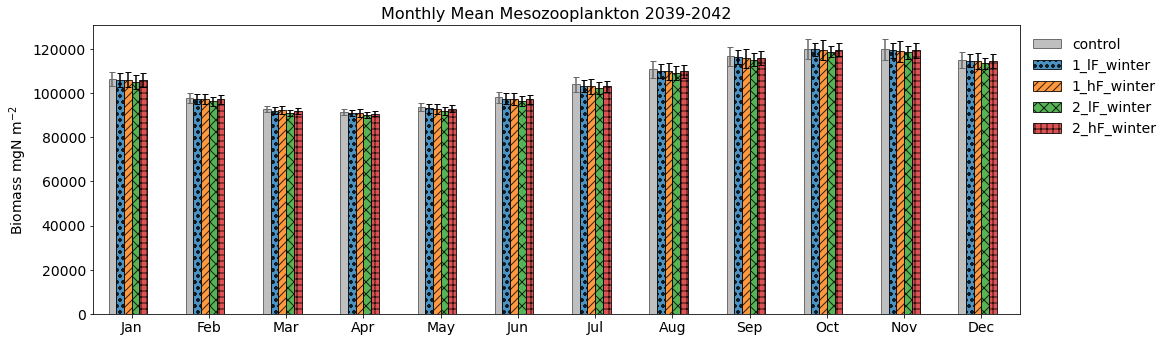

In [24]:
fig, ax = plt.subplots(figsize=(14, 5))

fig.tight_layout(pad=2.5)

bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 1}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
these_hatches = itertools.cycle(hatches)

width=0.1

control_tbl = control.Zoo_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 

ax.bar(xticks-0.25, control_monthly_mean,width,yerr=control_std,color='grey',ecolor='dimgrey',edgecolor='k',label='control',alpha=0.5,capsize=3) #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.Zoo_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]
    offset = ((list(scenario_paths).index(path))- len(scenario_paths)/2) * width + width/2
    ax.bar(xticks + offset, scenario_monthly_mean,width,yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,label=name) #lightgreen
    #ax.fill_between(xticks,NPGO_C_D_mean,color='black',hatch='//',alpha=.3,label='Diatoms') #lightgreen
    #offset = offset + 0.1
    
ax.set_title('Monthly Mean Mesozooplankton 2039-2042',fontsize=16)
ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14)
#ax.set_ylim(0,35000)
ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

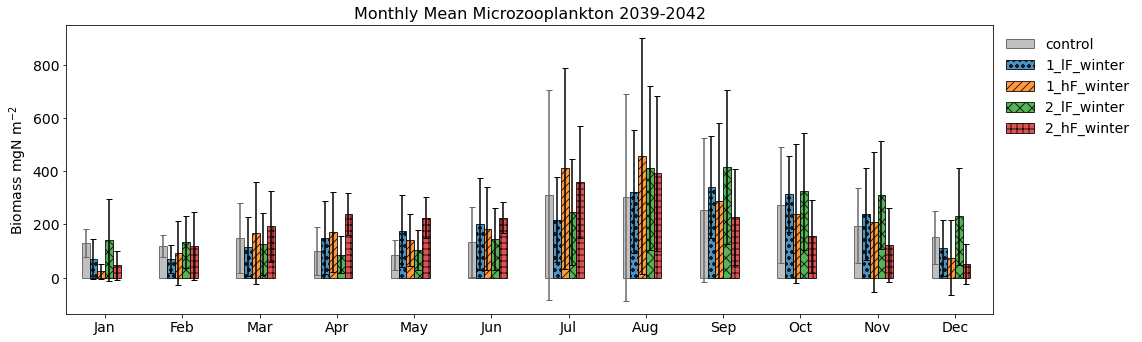

In [25]:
fig, ax = plt.subplots(figsize=(14, 5))

fig.tight_layout(pad=2.5)

bbox = {'boxstyle': 'round', 'facecolor': 'w', 'alpha': 1}
cmap = plt.get_cmap('tab10')
palette = [cmap(0), cmap(0.2), 'k', cmap(0.1), cmap(0.3)]
these_hatches = itertools.cycle(hatches)

width=0.1

control_tbl = control.MicroZoo_N[start:end,location,0:6]
control_t = control_tbl.sum(axis=(1,2))
control_monthly_mean = control_t.groupby("t.month").mean("t")
control_std = control_t.groupby("t.month").std("t")
xticks=np.arange(len(control_monthly_mean)) 

ax.bar(xticks-0.25, control_monthly_mean,width,yerr=control_std,color='grey',ecolor='dimgrey',edgecolor='k',label='control',alpha=0.5,capsize=3) #wheat

for scenario, path in zip(scenario_datasets, scenario_paths):
    scenario_tbl = scenario.MicroZoo_N[start:end,location,0:6]
    scenario_t = scenario_tbl.sum(axis=(1,2))
    scenario_monthly_mean = scenario_t.groupby("t.month").mean("t")
    scenario_std = scenario_t.groupby("t.month").std("t")

    nm = str(path.parent.stem).split(sep='_')
    name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]
    offset = ((list(scenario_paths).index(path))- len(scenario_paths)/2) * width + width/2
    ax.bar(xticks + offset, scenario_monthly_mean,width,yerr=scenario_std, edgecolor='black', hatch=next(these_hatches), alpha=0.8,capsize=3,label=name) #lightgreen
    #ax.fill_between(xticks,NPGO_C_D_mean,color='black',hatch='//',alpha=.3,label='Diatoms') #lightgreen
    #offset = offset + 0.1
    
ax.set_title('Monthly Mean Microzooplankton 2039-2042',fontsize=16)
ax.legend(frameon=False, bbox_to_anchor=(1, 1),  fontsize=14)
#ax.set_ylim(0,35000)
ax.set_xlim(-.5,11.5)
ax.set_ylabel('Biomass mgN m$^{-2}$',fontsize=14)
ax.xaxis.set_tick_params(labelsize=14)
ax.yaxis.set_tick_params(labelsize=14)
#ax.text(-.25, 50, "(b)", color='k',fontsize=16)
ax.set_xticks(xticks)
ax.set_xticklabels(('Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov',"Dec"));

## Scenario comparison across all pelagic groups

In [26]:
def compute_mean_N_pelagic(bio_group, location=groups.salish_sea, v_min=None, v_max=None):
    all_results = []
    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = nm[2]+'_'+groups.condition_labels[groups.conditions[nm[3]]]

        for species in bio_group:
            
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, :], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, :], np.nan)
            
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
            
            ratio = (p_oiled / p_control - 1) * 100

            all_results.append({
                'bio_group': bio_group[species],
                'scenario': scenario_name,
                'percent_change': ratio
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/meanN_"+scenario_name+".csv")

In [ ]:
compute_mean_N_pelagic(groups.all_pelagic)

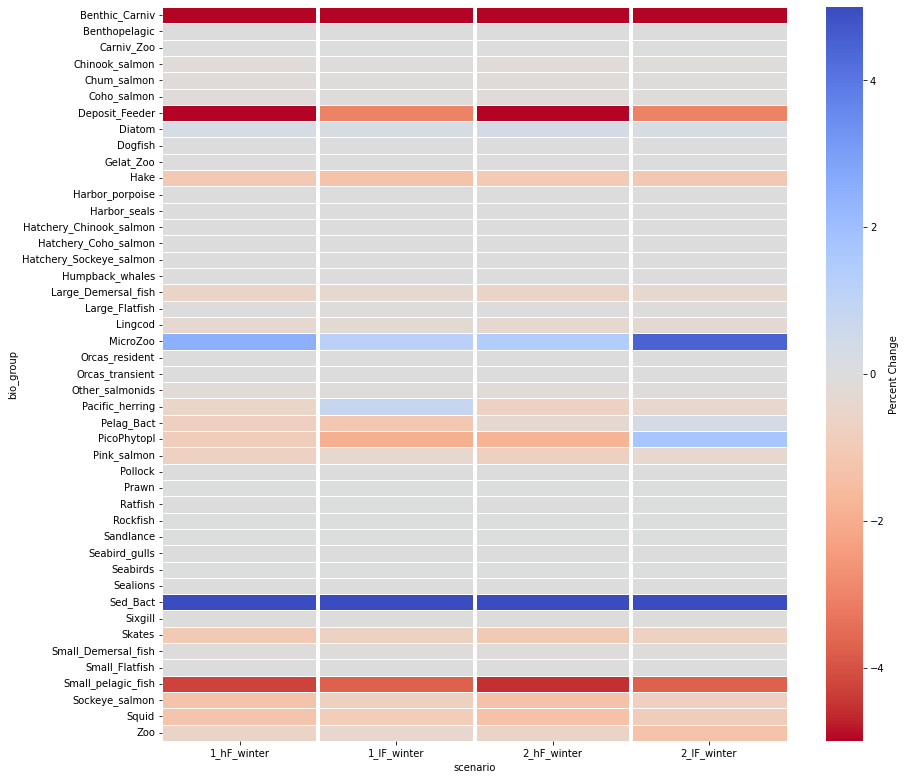

In [27]:
scenario_name = '2_hF_winter'
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/meanN_"+scenario_name+".csv")
df_pivot = df.pivot_table(index='bio_group', 
                        columns='scenario', 
                        values='percent_change', 
                        )

#sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0)
plt.figure(figsize=(14, len(df_pivot)*0.3))
ax = sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0, vmin=-5, vmax=5,
    linewidths=0.5,
    #linecolor='gray',
    cbar_kws={'label': 'Percent Change'})
location_boundaries = []
prev_loc = None
for i, col in enumerate(df_pivot.columns):
    loc = col.split('-')[0]
    if prev_loc is not None and loc != prev_loc:
        location_boundaries.append(i)
    prev_loc = loc

for x in location_boundaries:
    ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=4)

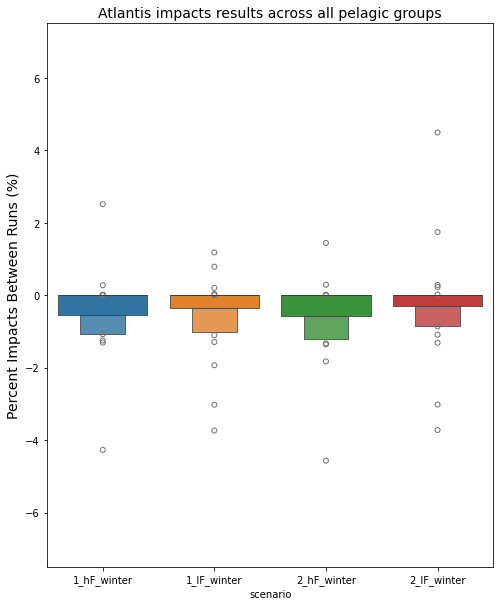

In [29]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(df_pivot) 
plt.ylim(-7.5, 7.5)
plt.ylabel('Percent Impacts (%)', fontsize = 14)
plt.title('Atlantis impacts results across all pelagic groups', fontsize = 14);

Boxen plots: innermost box is drawn at the lower and upper fourths, incrementally narrower box is drawn between at the lower and upper eighths, and narrower one still at the lower and upper sixteenths (not applicable on this dataset). Tails show the remaining data that exceed the boxes. See the heatmap to know which functional groups correspond to the tails for the scenarios & simulations shown.

Reminder
| Scenarios	|	Description |
|-----------|---------------|
| 1	|	30-day fisheries closures |
| 2	|	90-day fisheries closures |
| 3	|	spill containment within 48hrs + 30-day fisheries closures |
| 4	|	spill containment within 48hrs + 90-day fisheries closures |

### Comparing scenarios 1 and 2 with a control of a spill but with no fisheries closures

In [4]:
mpri1_scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/')
mpri1_scenario_paths = sorted([p for p in mpri1_scenario_root.glob('highres-2039-2042_5b*/outputSalishSea.nc')])
for path in mpri1_scenario_paths:
    print(path.parent.stem)

highres-2039-2042_5b_1_2019-01-20
highres-2039-2042_5b_2_2019-01-14
highres-2039-2042_5b_3_2020-01-24
highres-2039-2042_5b_4_2020-01-16


In [5]:
mpri1_scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in mpri1_scenario_paths]

In [6]:
mpri1_control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2039-2042/outputSalishSea.nc"
mpri1_control = xr.open_dataset(str(mpri1_control_file), decode_cf=True)

In [14]:
location = groups.salish_sea
all_compare = []

bio_group = groups.all_pelagic  
for scenario, path in zip(mpri1_scenario_datasets[0:1], mpri1_scenario_paths[0:1]):
    nm = str(path.parent.stem).split(sep='_')
    scenario_name = 'no_closure_'+groups.condition_labels[groups.conditions[nm[3]]]
    print(scenario_name)
    for species in bio_group:
        
        p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, :], np.nan)
        p_control = np.ma.filled(mpri1_control.variables[bio_group[species] + '_N'][:, location, :], np.nan)
        
        p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
        p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
        
        ratio = (p_oiled / p_control - 1) * 100

        all_compare.append({
            'bio_group': bio_group[species],
            'scenario': scenario_name,
            'percent_change': ratio
        })
for scenario, path in zip(mpri1_scenario_datasets[2:3], mpri1_scenario_paths[2:3]):
    nm = str(path.parent.stem).split(sep='_')
    scenario_name = 'no_closure_'+groups.condition_labels[groups.conditions[nm[3]]]
    print(scenario_name)
    for species in bio_group:
        
        p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, :], np.nan)
        p_control = np.ma.filled(mpri1_control.variables[bio_group[species] + '_N'][:, location, :], np.nan)
        
        p_oiled = p_oiled.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
        p_control = p_control.sum(axis=(1, 2)).mean()+groups.base_biomass[bio_group[species]]
        
        ratio = (p_oiled / p_control - 1) * 100

        all_compare.append({
            'bio_group': bio_group[species],
            'scenario': scenario_name,
            'percent_change': ratio
        })

df = pd.DataFrame(all_compare)
df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/meanN_mpri1_5b_winter.csv")

no_closure_lF_winter
no_closure_hF_winter


In [15]:
results_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/')
results_paths = sorted([p for p in results_root.glob('meanN*.csv')])
compare_winter_closures = []
for file in results_paths:
    df1 = pd.read_csv(file)
    compare_winter_closures.append(df1[['bio_group', 'scenario', 'percent_change']])

compare_winter_closures_df = pd.concat(compare_winter_closures, ignore_index=True)
compare_winter_closures_df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/compare_5b_winter_closures.csv")

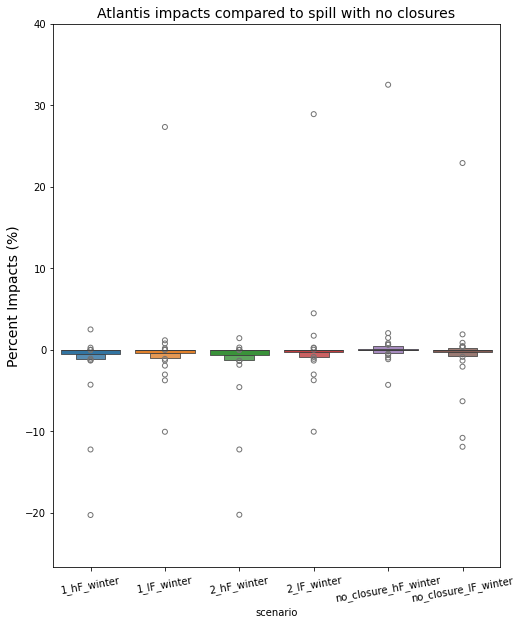

In [20]:
c_df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/compare_5b_winter_closures.csv")
compare_closures = c_df.pivot_table(index='bio_group', 
                        columns='scenario', 
                        values='percent_change', 
                        )
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(compare_closures) 
plt.ylim(None,40)
plt.xticks(rotation=10)
plt.ylabel('Percent Impacts (%)', fontsize = 14)
plt.title('Atlantis impacts compared to spill with no closures', fontsize = 14);

Rough comparison - not yet a true comparison because the no_closure scenarios are taken from injection at the surface only, whereas the other scenarios are injections at the surface + depth. Need to do no_closure scenario runs under the same conditions at the current simulations.